In [ ]:

import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
model_names = {
 1: 'genetics_and_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 2: 'genetics_and_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 3: 'genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10',
 4: 'genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0',
 5: 'only_genetics_ct_batch_cancertypebatching_exp_0_warmup_0',
 6: 'only_genetics_ct_batch_cancertypebatching_exp_1_warmup_10',
 7: 'only_genetics_all_batch_cancertypebatching_exp_0_phase2_10',
 8: 'only_genetics_all_batch_cancertypebatching_exp_1_phase2_0',
 9: 'only_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 10: 'only_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 11: 'only_image_all_batch_cancertypebatching_exp_0_phase2_10',
 12: 'only_image_all_batch_cancertypebatching_exp_1_phase2_0'
}

name_models = { v: k for k, v in model_names.items() }


In [3]:
# Initialize a results dictionary that will store data from both existing and new models
all_results = defaultdict(list)

# %% 
# Existing models loop: these files are in /n/data2/...
for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['ct_batch', 'all_batch']:
        for exp in ['cancertypebatching_exp_0_warmup_0', 
                    'cancertypebatching_exp_1_warmup_10', 
                    'cancertypebatching_exp_0_phase2_10', 
                    'cancertypebatching_exp_1_phase2_0']:
            path = f"/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)
            except Exception as e:
                # For troubleshooting, you might print(e)
                pass


In [8]:
# New improved fusion models
# We have two groups: one for "layer_norm_fusion_mlp" and one for "layer_norm_fusion_mlp_lowerlr"
# Their files are stored under /home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing/
improved_models = {
    "layer_norm_fusion_mlp": ["cancertypebatching_exp_0_phase2_10", "cancertypebatching_exp_1_phase2_0"],
    "layer_norm_fusion_mlp_lowerlr": ["cancertypebatching_exp_0_phase2_10", "cancertypebatching_exp_1_phase2_0"]
}
base_improved_path = "/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing"

for model_type, exp_list in improved_models.items():
    for exp in exp_list:
        # Build path for each improved model
        path = f"{base_improved_path}/{model_type}/{exp}/global_test_cindices.csv"
        try:
            data = pd.read_csv(path)
            for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                # Here we record the improved model using its folder name. 
                # Since there's no "batch" in the directory structure, we label it as "improved"
                all_results['gen_image'].append(model_type)
                all_results['batch'].append("improved")
                all_results['exp'].append(exp)
                all_results['cancer'].append(cancer)
                all_results['c_index'].append(c_idx)
        except Exception as e:
            # Uncomment the next line if you wish to debug missing files:
            # print(f"Could not read {path}: {e}")
            pass


In [5]:
df = pd.DataFrame(all_results)
df.to_csv("./test_df.csv", index=False)

# %%
# Group by the required columns and compute the mean and standard error
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]
grouped.to_csv("grouped.csv", index=False)
grouped

# %%
df = grouped.copy()

# Calculate 95% Confidence Interval = 1.96 * standard error
df["ci95"] = 1.96 * df["se_c_index"]

TypeError: range expected at least 1 argument, got 0

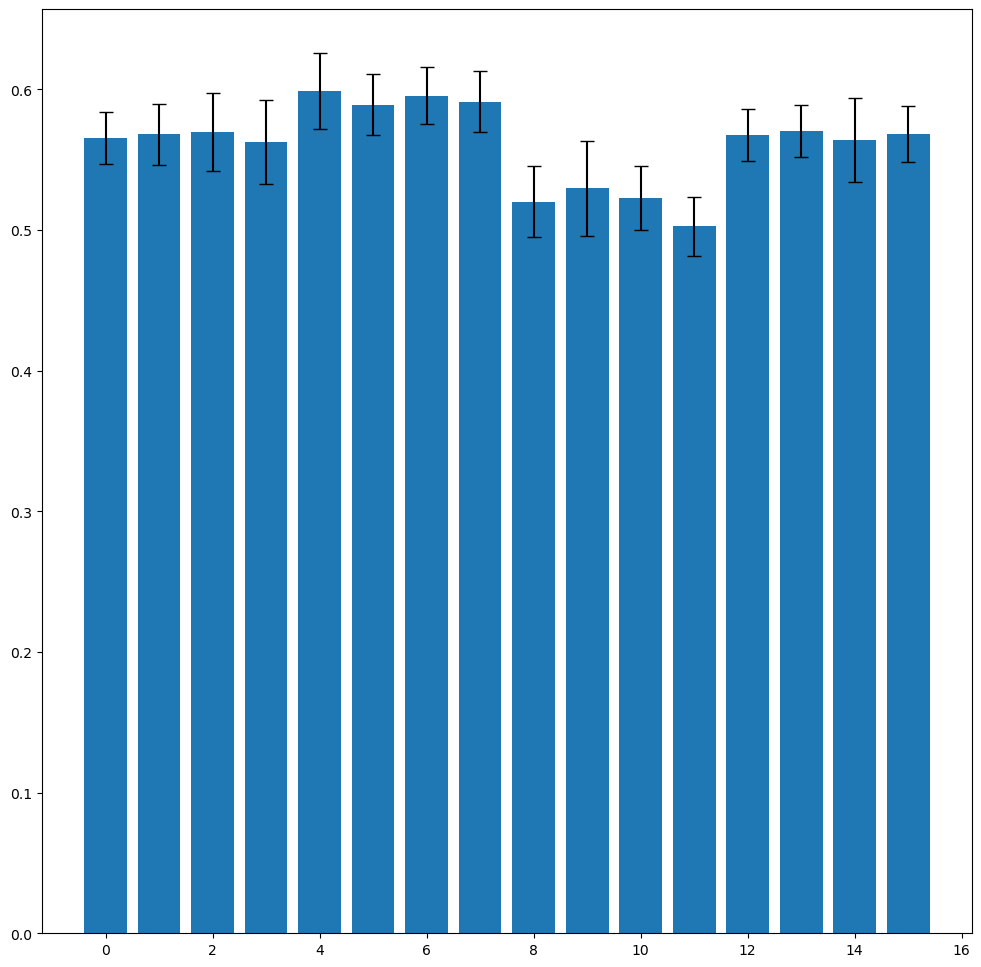

In [6]:
# Initial Plot (without improved models specifically labeled)
plt.figure(figsize=(12, 12))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5)
plt.xticks(range(len(df)), range(), rotation=90)
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.show()

# %%
# If you have a model_names mapping (only for original models), you might want to map or sort differently.
grouped["model_name"] = grouped["model"].map(name_models)
grouped.sort_values("model_name", inplace=True)
grouped.reset_index(drop=True, inplace=True)

df = grouped.copy()

ValueError: The number of FixedLocator locations (16), usually from a call to set_ticks, does not match the number of labels (12).

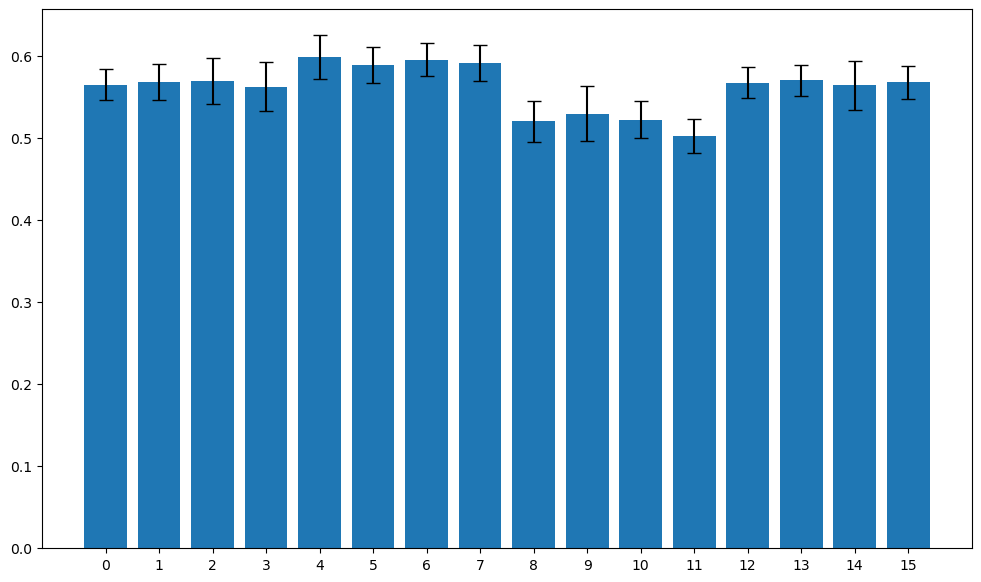

In [9]:

# Calculate 95% CI again
df["ci95"] = 1.96 * df["se_c_index"]

# Plot with sorted original model names (if applicable)
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5)
plt.xticks(range(len(df)), range(1, 13))
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.show()

In [ ]:
# Update the grouping for visualization by categorizing models.
# Modify get_group so that it also identifies the improved models.
def get_group(model_str):
    if "layer_norm_fusion_mlp_lowerlr" in model_str:
        return "Improved Fusion (Lower LR)"
    elif "layer_norm_fusion_mlp" in model_str:
        return "Improved Fusion"
    elif "genetics_and_image" in model_str:
        return "Genetics and Image"
    elif "only_genetics" in model_str:4
        return "Only Genetics"
    elif "only_image" in model_str:
        return "Only Image"
    else:
        return "Other"

df["group"] = df["model"].map(get_group)


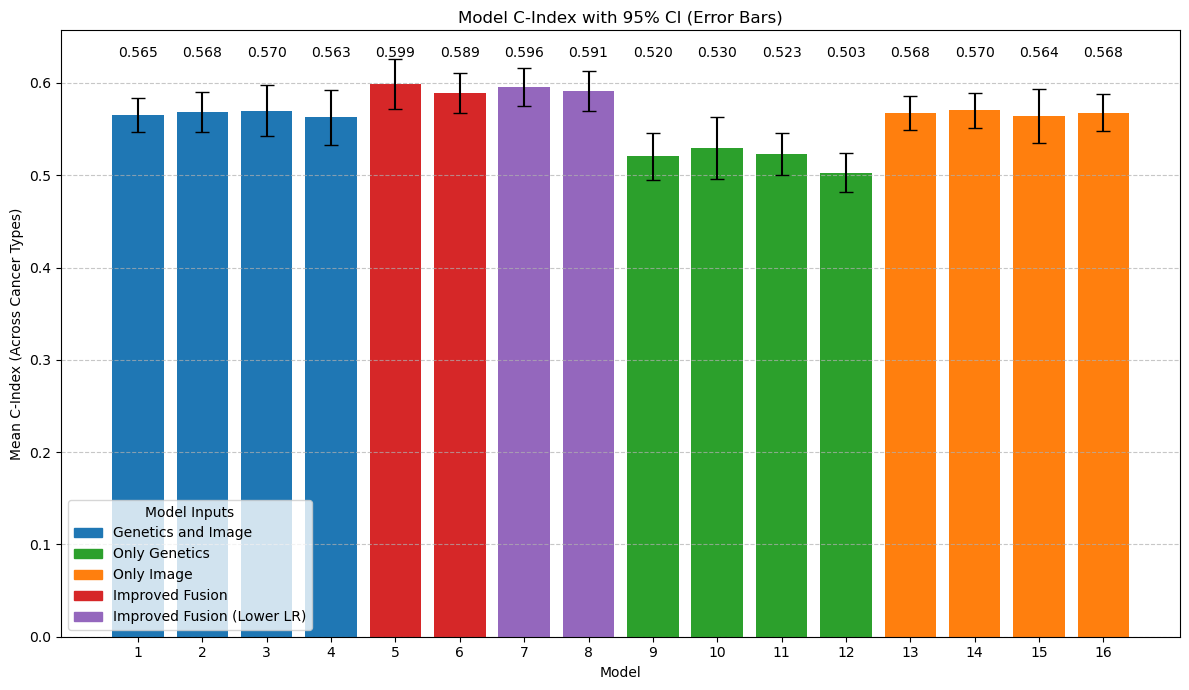

In [17]:

# Assign a distinct color to each group (colors here are arbitrary)
color_map = {
    "Genetics and Image": "tab:blue",
    "Only Genetics": "tab:green",
    "Only Image": "tab:orange",
    "Improved Fusion": "tab:red",
    "Improved Fusion (Lower LR)": "tab:purple"
}

colors = df["group"].map(color_map)

# Plot with grouped colors
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5, color=colors)
plt.xticks(range(len(df)), range(1, len(df)+1))
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.625, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Add legend
legend_patches = [mpatches.Patch(color=color_map[group], label=group) for group in color_map]
plt.legend(handles=legend_patches, title="Model Inputs")

plt.show()

In [27]:
# Use the grouped df row directly
best_row = df.loc[df[df["group"].isin(["Improved Fusion", "Improved Fusion (Lower LR)"])]["avg_c_index"].idxmax()]
gi_best = best_row["gen_image"]
batch_best = best_row["batch"]
exp_best = best_row["exp"]

print(f"Best model info:\ngen_image: {gi_best}\nbatch: {batch_best}\nexp: {exp_best}")

# Now get matching raw c-indices
best_improved_cindices = raw_df[
    (raw_df["gen_image"] == gi_best) &
    (raw_df["batch"] == batch_best) &
    (raw_df["exp"] == exp_best)
]["c_index"].dropna().values
print("Best improved c-index values:", best_improved_cindices)
print("Count:", len(best_improved_cindices))


Best model info:
gen_image: layer_norm_fusion_mlp
batch: improved
exp: cancertypebatching_exp_0_phase2_10
Best improved c-index values: [0.52908335 0.6045961  0.51990856 0.7309417  0.59708645 0.65686307
 0.50347594 0.67894206 0.523102   0.52301207 0.54618812 0.81276596
 0.53745375 0.56521739 0.57530147 0.74230387 0.57639885 0.59232517
 0.54111406 0.54832347 0.67746114 0.46169666 0.59179785 0.61039629
 0.52461501 0.68135593 0.72102564 0.66343259 0.55707062 0.62170088
 0.56221532 0.58006463 0.5995023 ]
Count: 33


In [28]:
# inside loop:
image_cindices = raw_df[
    (raw_df["gen_image"] == gi) &
    (raw_df["batch"] == batch) &
    (raw_df["exp"] == exp)
]["c_index"].dropna().values


In [29]:
image_cindices

array([], dtype=float64)

/home/chb3333/.conda/envs/nns/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


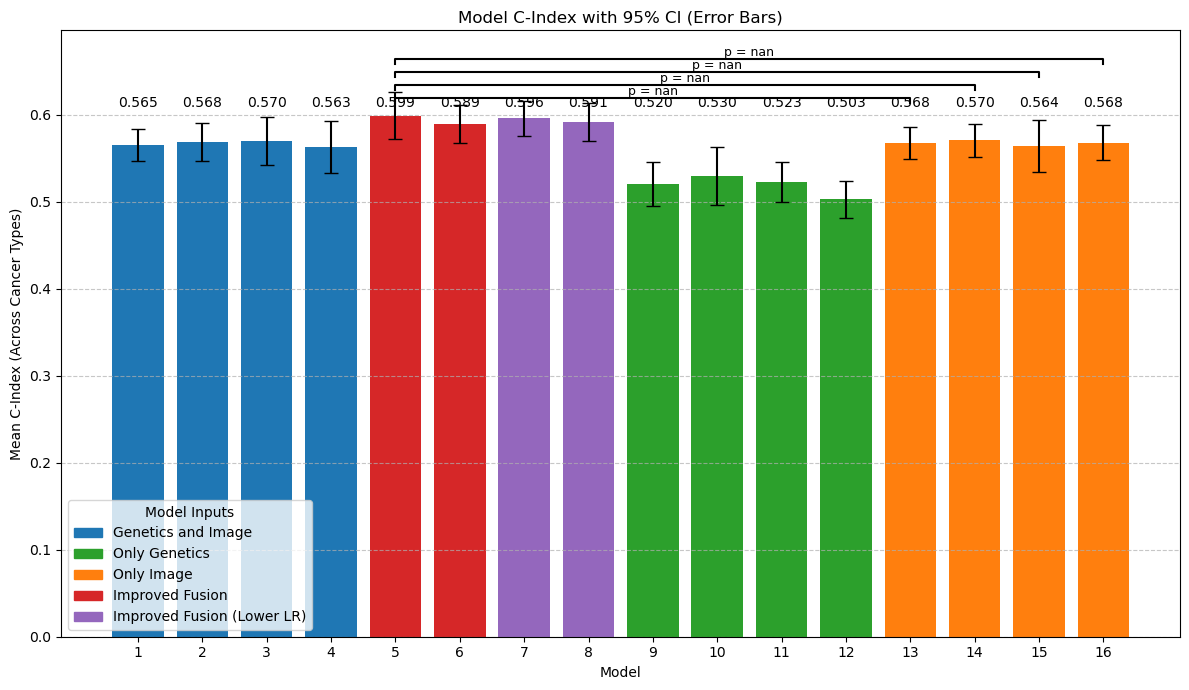

In [26]:
from scipy.stats import ttest_ind

# Load the raw per-cancer results again
raw_df = pd.read_csv("test_df.csv")

# Identify the best improved model (same as before)
best_improved_group = df[df["group"].isin(["Improved Fusion", "Improved Fusion (Lower LR)"])]
best_improved_row = best_improved_group.loc[best_improved_group["avg_c_index"].idxmax()]
best_model_id = best_improved_row["model"]

# Parse out its components to match raw_df
gi_best, batch_best, exp_best = best_model_id.split("_", maxsplit=2)

# Get all c-index values for that model from raw data
best_improved_cindices = raw_df[
    (raw_df["gen_image"] == gi_best) &
    (raw_df["batch"] == batch_best) &
    (raw_df["exp"] == exp_best)
]["c_index"].values

# Prepare plotting again
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5, color=colors)
plt.xticks(range(len(df)), range(1, len(df)+1))
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add bar value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Compare to each Only Image model
only_image_df = df[df["group"] == "Only Image"]
y_offset = 0.015
text_offset = 0.005
bracket_height = []

for i, row in only_image_df.iterrows():
    # Get raw c-index values
    gi, batch, exp = row["model"].split("_", maxsplit=2)
    image_cindices = raw_df[
        (raw_df["gen_image"] == gi) &
        (raw_df["batch"] == batch) &
        (raw_df["exp"] == exp)
    ]["c_index"].values
    
    # Run t-test
    stat, p_val = ttest_ind(best_improved_cindices, image_cindices, equal_var=False)
    
    # Plot bracket
    idx1 = df[df["model"] == best_model_id].index[0]
    idx2 = df[df["model"] == row["model"]].index[0]
    x1 = bars[idx1].get_x() + bars[idx1].get_width()/2
    x2 = bars[idx2].get_x() + bars[idx2].get_width()/2
    y1 = bars[idx1].get_height()
    y2 = bars[idx2].get_height()
    y = max(y1, y2) + y_offset + len(bracket_height) * 0.015
    bracket_height.append(y)
    
    plt.plot([x1, x1, x2, x2], [y, y + 0.005, y + 0.005, y], lw=1.5, c='k')
    plt.text((x1 + x2) / 2, y + text_offset, f'p = {p_val:.3f}', ha='center', va='bottom', fontsize=9)

# Add legend
legend_patches = [mpatches.Patch(color=color_map[group], label=group) for group in color_map]
plt.legend(handles=legend_patches, title="Model Inputs")

plt.show()


In [20]:
best_improved_data = df[df["model"] == best_improved_model]["avg_c_index"].values


In [23]:
p_val

np.float64(nan)